In [1]:
import torch 
import torch.nn as nn 
import numpy as np
import matplotlib.pyplot as plt 

from sklearn import datasets

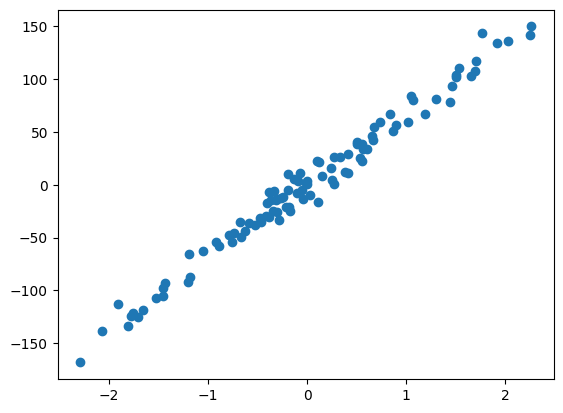

In [2]:
X_numpy,y_numpy = datasets.make_regression(100,1,noise=10,random_state=7)
plt.scatter(X_numpy,y_numpy)

In [3]:
X = torch.from_numpy(X_numpy.astype('float32'))
y = torch.from_numpy(y_numpy.astype('float32'))

print(X.size())
print(y.size()) # In pytorch, force same shape. Importacnce!!!!!!!!!!!!!
y = y.view(-1,1)
print(y.size())

torch.Size([100, 1])
torch.Size([100])
torch.Size([100, 1])


In [4]:
input_size = X.size()[1]
output_size = 1


model = nn.Sequential(
    nn.Linear(input_size, 3),
    nn.Linear(3, output_size)
)

learning_rate = 0.01
criterion = nn.MSELoss()
optim = torch.optim.SGD(model.parameters() , lr=learning_rate)

In [67]:
for name, param in model.named_parameters():
    print(f"{name}:\n{param.data}\n")

0.weight:
tensor([[-0.1870],
        [-0.2219],
        [ 0.1355]])

0.bias:
tensor([-0.8547,  0.2648, -0.5584])

1.weight:
tensor([[ 0.5537, -0.3062,  0.5071]])

1.bias:
tensor([-0.0900])



In [ ]:
# print(model.weight) use 1 param
# print(model.bias)

In [70]:
n_epoch = 100

for epoch in range(n_epoch):
    #forward pass 
    y_predicted = model(X) #output = X.matmul(weight.t()) + bias
    loss = criterion(y_predicted,y)

    #backward pass
    loss.backward()

    #update 
    optim.step()
    optim.zero_grad()

    print(f'epoch {epoch+1} | MSE {loss}')



epoch 1 | MSE 4795.33154296875
epoch 2 | MSE 4644.193359375
epoch 3 | MSE 3948.963134765625
epoch 4 | MSE 1352.045654296875
epoch 5 | MSE 959.0032958984375
epoch 6 | MSE 2882.4072265625
epoch 7 | MSE 94.5611801147461
epoch 8 | MSE 94.47012329101562
epoch 9 | MSE 96.52050018310547
epoch 10 | MSE 103.12503051757812
epoch 11 | MSE 125.91854858398438
epoch 12 | MSE 188.67257690429688
epoch 13 | MSE 428.5287170410156
epoch 14 | MSE 780.1090698242188
epoch 15 | MSE 2397.691162109375
epoch 16 | MSE 236.46388244628906
epoch 17 | MSE 600.4443969726562
epoch 18 | MSE 961.3574829101562
epoch 19 | MSE 2894.660400390625
epoch 20 | MSE 94.31010437011719
epoch 21 | MSE 96.20417785644531
epoch 22 | MSE 102.59844970703125
epoch 23 | MSE 121.68252563476562
epoch 24 | MSE 190.04791259765625
epoch 25 | MSE 351.59063720703125
epoch 26 | MSE 1011.11083984375
epoch 27 | MSE 1090.46044921875
epoch 28 | MSE 3213.001220703125
epoch 29 | MSE 201.1505889892578
epoch 30 | MSE 377.20379638671875
epoch 31 | MSE 1100